In [1]:
import sys
!{sys.executable} -m pip install opencv-python

# Then import
import cv2
print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.13.0


In [2]:
#Task#1: Thresholding
#Step#1: Apply thresholding with a fixed threshold on an image:

import cv2
# Load the image in grayscale
img1 = cv2.imread('/home/norah/code/wwwww22345/ARTI407-Lab4/image.png', cv2.IMREAD_GRAYSCALE)


In [3]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img1, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)
    # Display the original image
cv2.imshow('Original Image', img1)
cv2.waitKey(0)

QFontDatabase: Cannot find font directory /home/norah/.pyenv/versions/ai/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/norah/.pyenv/versions/ai/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/norah/.pyenv/versions/ai/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/norah/.pyenv/versions/ai/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font director

104

In [4]:
cv2.destroyAllWindows()

In [5]:
#Task#2: Histogram Processing
#Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure


In [6]:
#Step#2: Load moon image
img2 = data.moon()


/home/norah/.pyenv/versions/ai/lib/python3.12/site-packages/skimage/color/colorconv.py:55: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy import linalg


In [7]:
#Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img2, (2, 98))
img_rescale = exposure.rescale_intensity(img2, in_range=(p2, p98))



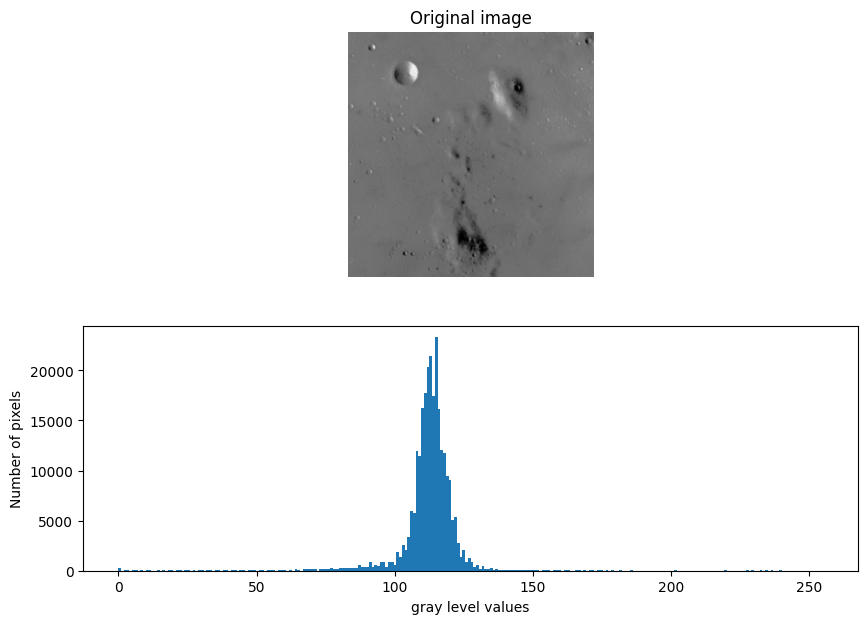

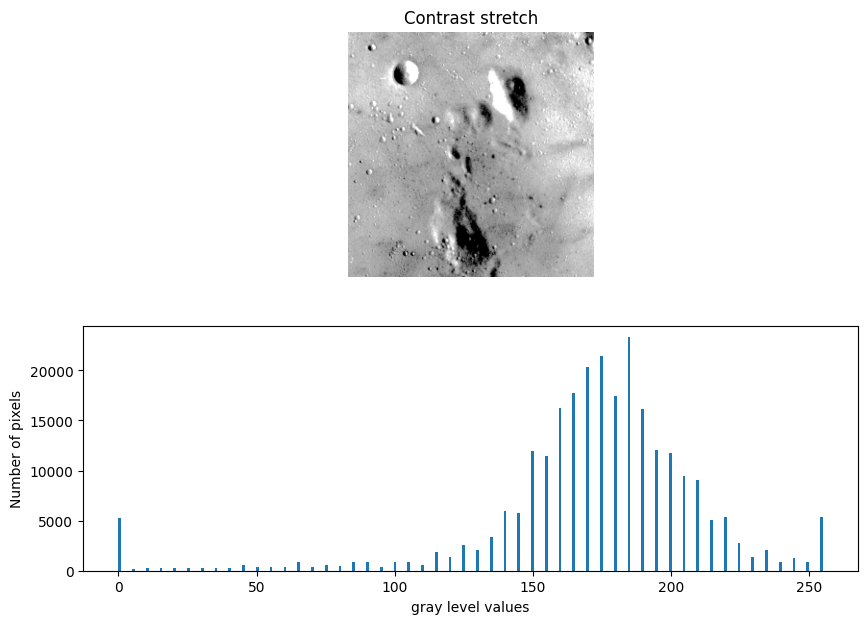

In [8]:
#Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img2, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img2.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 


**Task#1**
Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram


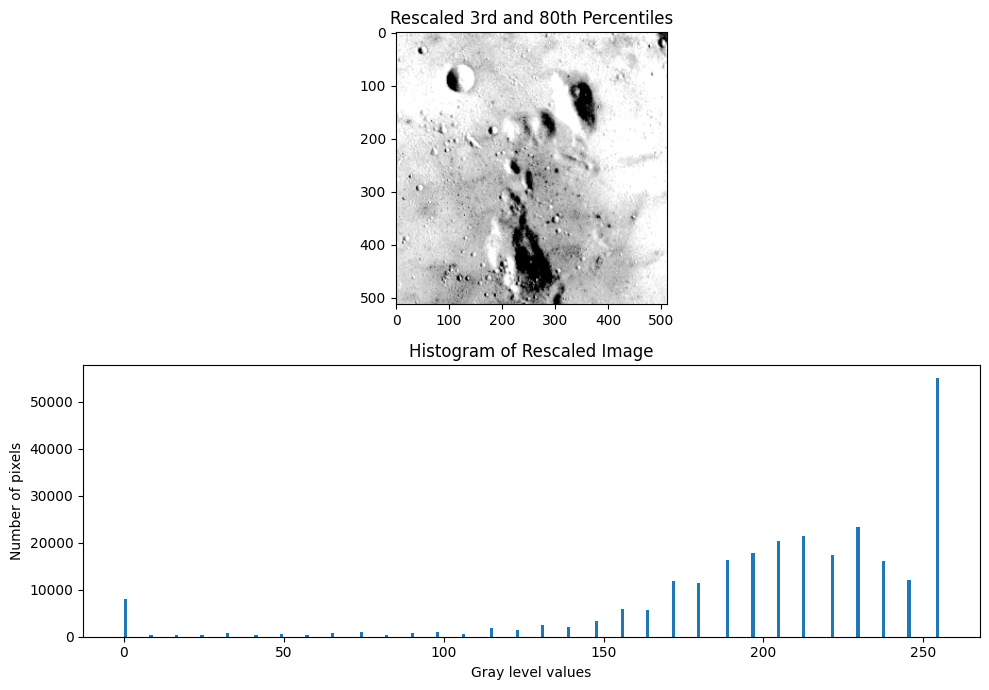

In [9]:
#Using numpy.percentile(img2, [3, 80]) calculates the 3rd and 80th percentiles 
#for the img2 data. This returns two values representing the thresholds below 
#which 3% and 80% of the pixel intensities
p3, p80 = np.percentile(img2, (3, 80))
img_rescale = exposure.rescale_intensity(img2, in_range=(p3, p80))

plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.title('Rescaled 3rd and 80th Percentiles')
#plt.axis('off')

plt.subplot(2, 1, 2)
plt.hist(img_rescale.ravel(), bins=256, range=(0, 255))
plt.title('Histogram of Rescaled Image')
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()

**Task#2** Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.


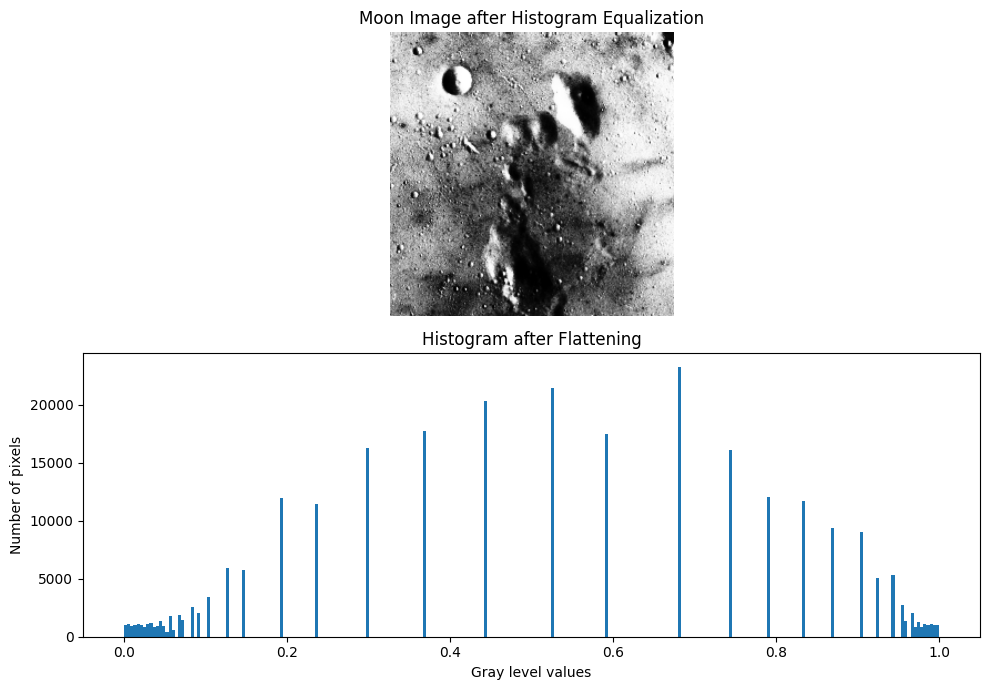

In [27]:
img_equalized = exposure.equalize_hist(img2)

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.title('Moon Image after Histogram Equalization')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.hist(img_equalized.ravel(), bins=256, range=(0, 1))
plt.title('Histogram after Flattening')
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()


**Task#3** Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


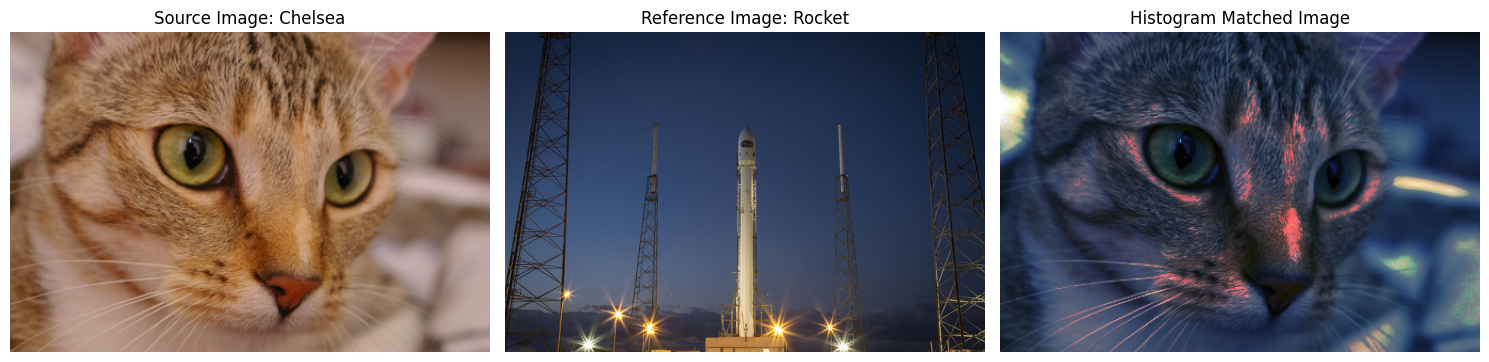

In [11]:
source = data.chelsea() # image to be changed
reference = data.rocket() # image used as reference

# Histogram matching
matched = exposure.match_histograms(source, reference, channel_axis=-1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(source)
plt.title('Source Image: Chelsea')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference)
plt.title('Reference Image: Rocket')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched)
plt.title('Histogram Matched Image')
plt.axis('off')

plt.tight_layout()
plt.show()